# How dependent is the method on shape measurement bias?
---

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from get_model_probabilities import *

import scienceplots
plt.style.use(["science","grid"])

Source redshift:1.36


In [4]:

ifilter = 'concat'

all_models = glob(f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth")[:5]
imonte=2


In [5]:



output_name = f"pickles/shape_measurement_{ifilter}_test.pkl"

#if os.path.isfile( output_name ):
#    all_results = pkl.load(open(output_name,"rb"))
#else:
all_results = {}
    
domain = {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
}
args.jwst_filter = 'concat'
args.apply_intrinsic_ell = 1.

zs = {
        'concat':1.46
}
args.zs = zs['concat']

test = 0
for c in [0, 0.02]:
    for m in [0,0.02]:
        for comp in ['e1','e2']:
            test += 1
            
            args.shape_measurement_bias = {'e1': {'c': 0, 'm': 0}, 'e2': {'c': 0, 'm': 0}}
            
            args.shape_measurement_bias[comp]['c'] = c
            args.shape_measurement_bias[comp]['m'] = m
    
            all_results[test] = {'bias':args.shape_measurement_bias}
    
    
    
            for imodel in tqdm(all_models):

                seed = imodel.split('_')[-7]

                print(seed)

                if f"seed_{seed}" in all_results[test].keys():
                    continue



                args.ignore_dataset = [''] # Althopiugh i ignored during training i want to see duringn testing.
                all_results[test][f"seed_{seed}"]  = {'src':[],'tgt':[]}

                args.log_mass_cut=0. # Make sure i test on equal mass clusters

                args.unbalance = False

                for i in range(imonte):
                    for idomain in domain.keys():

                        target_domain = domain[idomain]
                        results = get_probabilities( 
                                target_domain,
                                [imodel],
                                args,
                                quiet=True
                        )
                        del results['data_loaders']

                        all_results[test][f"seed_{seed}"][idomain].append( results )

            pkl.dump(all_results, open(output_name,"wb"))


  0%|                                                        | 0/5 [00:00<?, ?it/s]

2


 20%|█████████▍                                     | 1/5 [01:41<06:46, 101.56s/it]

12


 40%|██████████████████▊                            | 2/5 [03:21<05:02, 100.69s/it]

...

 60%|█████████████████████████▏                | 3/5 [4:14:35<2:19:05, 4172.86s/it]

29


 80%|█████████████████████████████████▌        | 4/5 [5:44:07<1:17:26, 4646.22s/it]

24


100%|████████████████████████████████████████████| 5/5 [7:17:09<00:00, 5245.99s/it]


In [6]:
output_name = f"pickles/shape_measurement_{ifilter}_test.pkl"
all_tests = pkl.load(open(output_name,'rb'))


PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/shape_measurement_bias.pdf'.


0

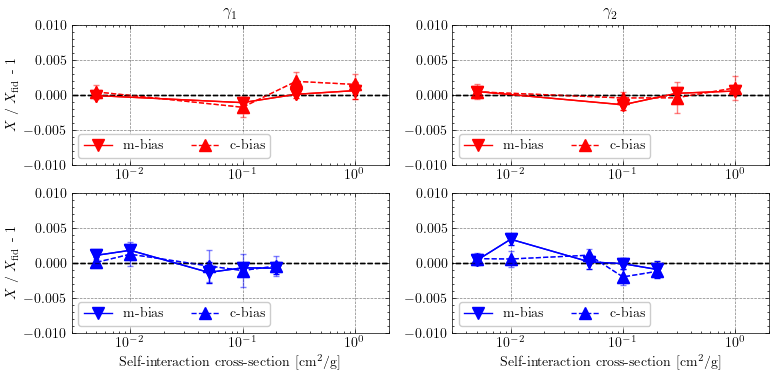

In [54]:
config='baha2dark'
filter_list  = ['concat']
cdm = 5e-3



domain = {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
}


output_name = f"pickles/shape_measurement_{ifilter}_test.pkl"

all_tests = pkl.load(open(output_name,'rb'))


fig, axarr = plt.subplots(2,2, figsize=(9,4))

ax = axarr[0]


color = {
        'src':'r',
        'tgt':'b'
    }

fid =  all_tests[1]

itest = 0

for ic, c in enumerate([0, 0.01]):
    for im in enumerate([0,0.01]):
        for icomp, comp in enumerate(['e1','e2']):
            
            
            itest += 1
    
            
            all_results = all_tests[itest]


            if all_results['bias'][comp]['m'] ==  all_results['bias'][comp]['c']:
                continue
            
            if all_results['bias'][comp]['m']  > 0:
                fmt='-v'
                label='m-bias'
                alpha=1
            else:
                fmt='--^'
                label='c-bias'
                alpha=0.5
            
            for itgt, target in enumerate(['src','tgt']):
                all_thresholds = []
                ax = axarr[itgt, icomp]
                for imodel in all_results.keys():
                    if imodel == 'bias':
                        continue


                    tgt = get_threshold_for_cross( 
                        all_results[imodel][target], 
                        mass_cut=None, 
                        dataset=domain[target].split('_')[0],
                        quiet=False)

                    ref = get_threshold_for_cross( 
                        fid[imodel][target], 
                        mass_cut=None, 
                        dataset=domain[target].split('_')[0],
                        quiet=False)

                    all_thresholds.append(tgt['thresholds']/ref['thresholds'])

                all_thresholds = np.array(all_thresholds)
                means = np.nanmean(all_thresholds,axis=0)
                errors = np.std(all_thresholds,axis=0) / np.sqrt(all_thresholds.shape[0]) 





                tgt['cross_sections'][0] += cdm
                ax.errorbar( tgt['cross_sections'], 
                            means-1,
                            errors,
                            fmt=fmt, 
                            capsize=2,
                            markersize=8,
                           color=color[target],
                           alpha=alpha)
                ax.plot( tgt['cross_sections'], 
                            means-1,
                            fmt, 
                            markersize=8, 
                            color=color[target],
                           label=label)
                
                
                ax.legend(loc=3, ncols=2)
                ax.plot([1e-4,10],[0,0],'k--')
                
                ax.set_xscale('log')
                ax.set_xlim(3e-3,2)
                
                if itgt == 0:
                    ax.set_title(f"$\{comp.replace('e','gamma_')}$")
            #ax.set_xscale('log')
                if itgt == 1:

                    ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
                    
                    
                axarr[icomp,0].set_ylabel("$X$ / $X_{\\rm fid}$ - 1")
                ax.set_ylim(-0.01,0.01)

            #ax.set_ylabel("Model threshold output")

            #
            #ax.set_xlim(3e-3,1)
            #ax.text(0.05,0.85,f"{isource_redshift}", transform=ax.transAxes,fontsize=12)
           
        #plot_observations( "pickles/model_on_data.pkl", 'concat', ax=ax, correction=3.6, fill_args={'alpha':0.2} )


        
fname="plots/shape_measurement_bias.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")